## 📘 Level 3 – Task 1: Predictive Modeling

### 🎯 Objective:
Build a regression model to predict restaurant `Aggregate rating` using features like votes, pricing, and service availability.


In [40]:
## Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, root_mean_squared_error

sns.set(style="whitegrid")
%matplotlib inline


In [41]:
# Load Preprocessed Dataset
df = pd.read_csv('C:/Users/Rajender Reddy/Desktop/DATA SCIENCE/Restaurant Insights Exploration/Level 1/preprocessed_dataset.csv')
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [46]:
## Categorical Features
# Convert 'Yes'/'No' columns to binary (0/1)
df['Has Table booking (bin)'] = df['Has Table booking'].map({'Yes': 1, 'No': 0})
df['Has Online delivery (bin)'] = df['Has Online delivery'].map({'Yes': 1, 'No': 0})

In [47]:
##  Select Features and Target
features = ['Votes', 'Price range', 'Has Table booking (bin)', 'Has Online delivery (bin)']
X = df[features]
y = df['Aggregate rating']


In [48]:
## split into Train and Test sets 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [49]:
## Training Models 
##1.  Linear Regression
# Train model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test)

# Evaluate
lr_r2 = r2_score(y_test, y_pred_lr)
lr_rmse = root_mean_squared_error(y_test, y_pred_lr)

print(f"📉 Linear Regression R²: {lr_r2:.3f}")
print(f"📉 Linear Regression RMSE: {lr_rmse:.3f}")

📉 Linear Regression R²: 0.263
📉 Linear Regression RMSE: 1.295


In [50]:
##2.Random Forest 
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
rf_r2 = r2_score(y_test, y_pred_rf)
rf_rmse = root_mean_squared_error(y_test, y_pred_rf)

print(f"🌲 Random Forest R²: {rf_r2:.3f}")
print(f"🌲 Random Forest RMSE: {rf_rmse:.3f}")


🌲 Random Forest R²: 0.931
🌲 Random Forest RMSE: 0.395


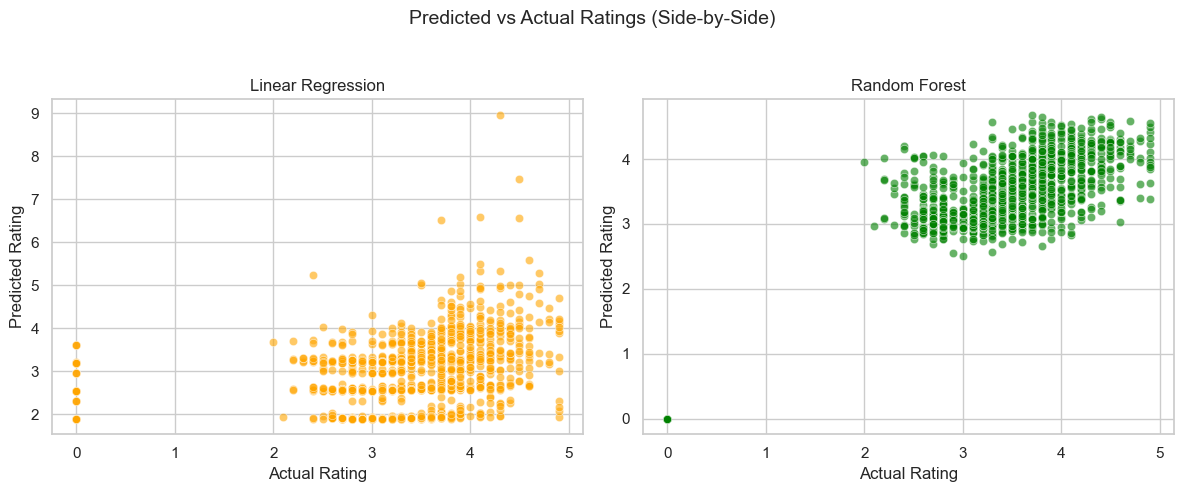

In [54]:
plt.figure(figsize=(12, 5))

# Linear Regression Plot
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.6, color='orange')
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Linear Regression")

# Random Forest Plot
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6, color='green')
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Random Forest")

plt.suptitle("Predicted vs Actual Ratings (Side-by-Side)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("side_by_side_prediction.png", dpi=300, bbox_inches="tight")
plt.show()


In [55]:
df.to_csv("model_ready_dataset.csv", index=False)
print("✅ Cleaned dataset saved as model_ready_dataset.csv")


✅ Cleaned dataset saved as model_ready_dataset.csv


In [58]:
print(f"""
📌 Model Evaluation Summary:

Linear Regression:
- R² Score  : {lr_r2:.3f}
- RMSE      : {lr_rmse:.3f}

Random Forest:
- R² Score  : {rf_r2:.3f}
- RMSE      : {rf_rmse:.3f}
""")



📌 Model Evaluation Summary:

Linear Regression:
- R² Score  : 0.263
- RMSE      : 1.295

Random Forest:
- R² Score  : 0.931
- RMSE      : 0.395



## 📊 Task 1 Completed


📊 Selected relevant features (`Votes`, `Price range`, delivery/booking availability)
- 🔁 Encoded categorical service columns to binary format
- 🔄 Split dataset into training and testing sets
- 🤖 Trained and evaluated:
  - Linear Regression
  - Random Forest Regressor
- 📈 Compared model performance using R² and RMSE
- 💾 Saved prediction plots as `.png`


### 📌 Outcome:
A working prediction model to estimate restaurant ratings, useful for quality forecasting and recommendation systems.

## 📘 Level 3 – Task 2: Customer Preference Analysis


### 🎯 Objective:
Analyze customer preferences based on cuisine types, popularity (votes), and satisfaction (ratings).


In [59]:
# Load Preprocessed Dataset
df = pd.read_csv('C:/Users/Rajender Reddy/Desktop/DATA SCIENCE/Restaurant Insights Exploration/Level 1/preprocessed_dataset.csv')
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [60]:
## Analyze Relationship Between Cuisine Type and Rating

## calculate average rating
avg_rating = df.groupby("Cuisines")["Aggregate rating"].mean().sort_values(ascending=False)


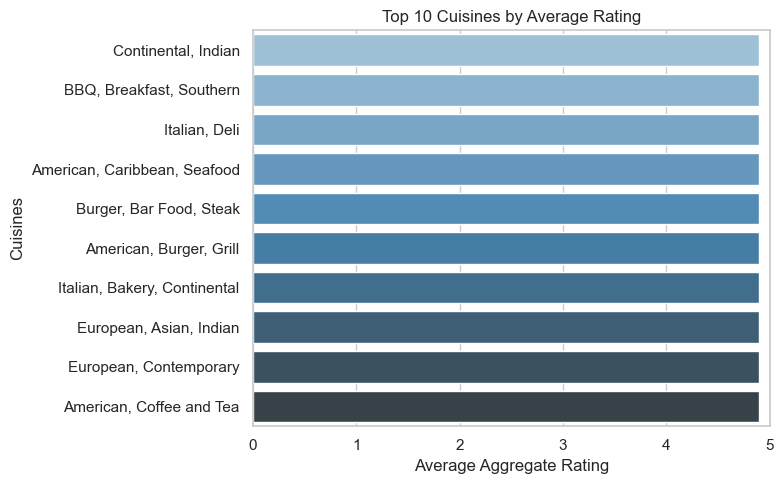

In [62]:
##  Top 10 cuisines by average rating

plt.figure(figsize=(8, 5))
sns.barplot(x=top_avg_rating.values, y=top_avg_rating.index,
            hue=top_avg_rating.index, legend=False, palette="Blues_d")
plt.xlabel("Average Aggregate Rating")
plt.title("Top 10 Cuisines by Average Rating")
plt.xlim(0, 5)
plt.tight_layout()
plt.savefig("top_cuisines_by_rating.png", dpi=300, bbox_inches="tight")
plt.show()


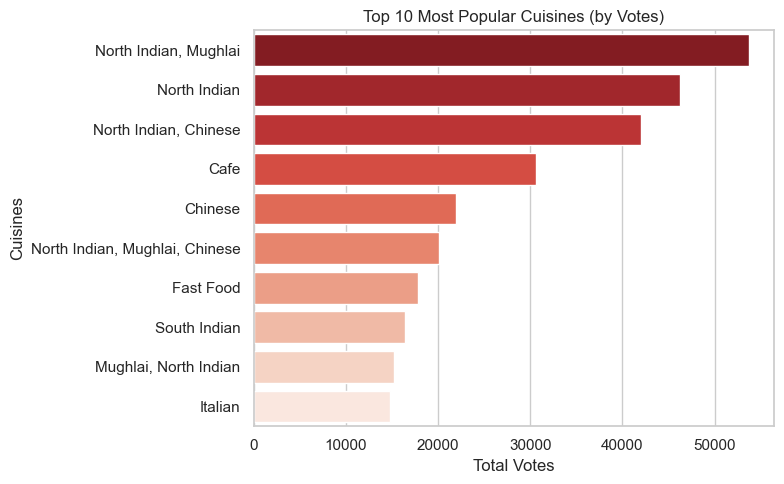

In [64]:
## Most Popular Cuisines by Number of Votes
plt.figure(figsize=(8, 5))
sns.barplot(
    x=popular_cuisines.values,
    y=popular_cuisines.index,
    hue=popular_cuisines.index,
    palette="Reds_r",
    legend=False
)
plt.xlabel("Total Votes")
plt.title("Top 10 Most Popular Cuisines (by Votes)")
plt.tight_layout()
plt.savefig("top_cuisines_by_votes.png", dpi=300, bbox_inches='tight')
plt.show()


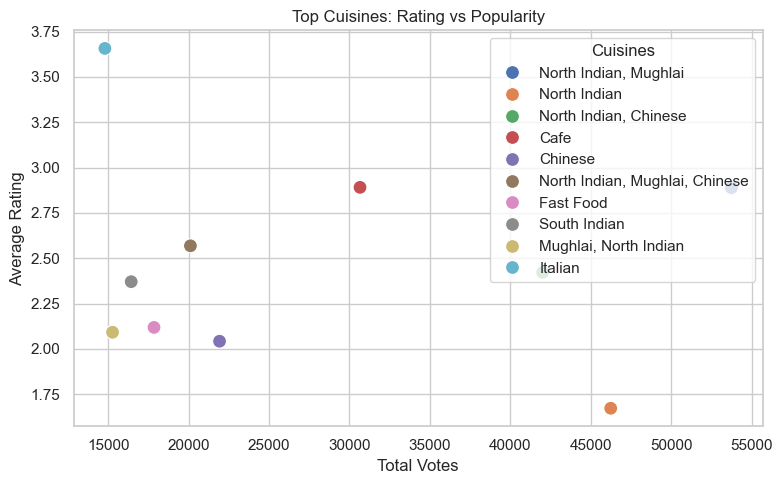

In [65]:
## Comparing  Ratings vs Popularity
cuisine_summary = df.groupby("Cuisines").agg({
    "Votes": "sum",
    "Aggregate rating": "mean"
}).sort_values(by="Votes", ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.scatterplot(x="Votes", y="Aggregate rating", data=cuisine_summary, hue=cuisine_summary.index, s=100)
plt.title("Top Cuisines: Rating vs Popularity")
plt.xlabel("Total Votes")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.savefig("cuisine_rating_vs_votes.png", dpi=300, bbox_inches="tight")
plt.show()

In [66]:
## output 
top_rated = top_avg_rating.index[0]
most_voted = popular_cuisines.index[0]

print(f"""
📌 Summary:

- 🍽️ Highest Rated Cuisine: {top_rated} with Avg Rating: {top_avg_rating.iloc[0]:.2f}
- 🔥 Most Popular Cuisine: {most_voted} with Votes: {popular_cuisines.iloc[0]}
- 📈 Charts saved:
    - top_cuisines_by_rating.png
    - top_cuisines_by_votes.png
    - cuisine_rating_vs_votes.png
""")



📌 Summary:

- 🍽️ Highest Rated Cuisine: Continental, Indian with Avg Rating: 4.90
- 🔥 Most Popular Cuisine: North Indian, Mughlai with Votes: 53747
- 📈 Charts saved:
    - top_cuisines_by_rating.png
    - top_cuisines_by_votes.png
    - cuisine_rating_vs_votes.png



## 📊 Task 2 Completed



- 🔍 Identified top 10 most common cuisines
- 📈 Calculated average `Aggregate rating` for each cuisine
- 📊 Analyzed total `Votes` per cuisine for popularity
- 💾 Saved all plots as `.png` files


### 📌 Outcome:
Clear insights into which cuisines are most popular and most liked, based on real customer behavior data.

## 📘 Level 3 – Task 3: Data Visualization


### 🎯 Objective:
Visualize rating distributions using different chart types.

Compare average ratings of different cuisines and cities.

Visualize relationships between features and the target variable.

In [68]:
df = pd.read_csv('C:/Users/Rajender Reddy/Desktop/DATA SCIENCE/Restaurant Insights Exploration/Level 1/preprocessed_dataset.csv')
df.head()


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


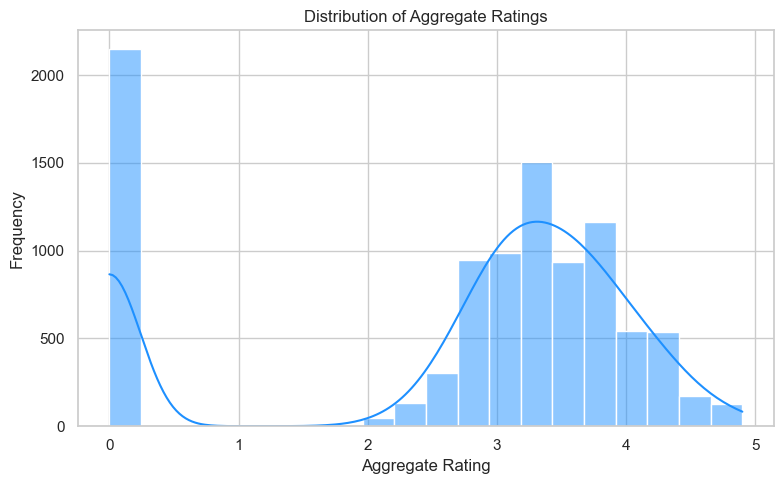

In [70]:
## Distribution of Aggregate Ratings

##1.Histogram
plt.figure(figsize=(8, 5))
sns.histplot(df["Aggregate rating"], bins=20, kde=True, color="dodgerblue")
plt.title("Distribution of Aggregate Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("rating_distribution_hist.png", dpi=300)
plt.show()


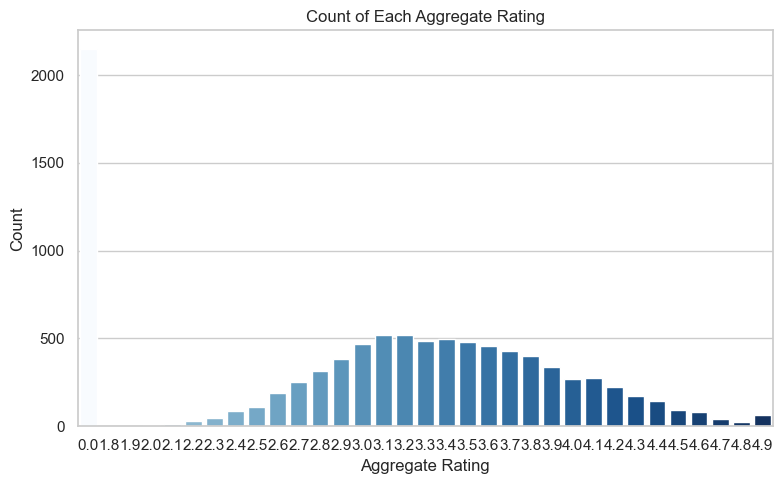

In [80]:
## 2. Bar PLot
plt.figure(figsize=(8, 5))
sns.countplot(x="Aggregate rating", data=df, hue="Aggregate rating", palette="Blues", legend=False)
plt.title("Count of Each Aggregate Rating")
plt.xlabel("Aggregate Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("rating_distribution_bar.png", dpi=300)
plt.show()


C:\Users\Rajender Reddy\AppData\Local\Temp\ipykernel_12084\4005615569.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette="crest")


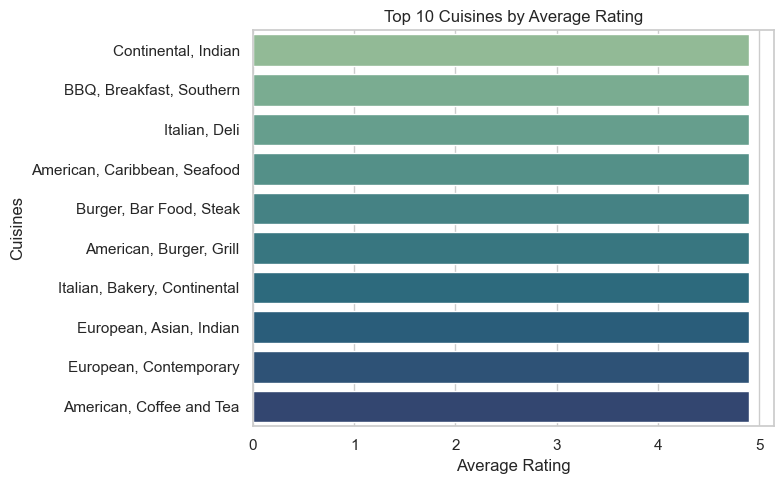

In [81]:
## Average Ratings by Cuisine
top_cuisines = df.groupby("Cuisines")["Aggregate rating"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette="crest")
plt.title("Top 10 Cuisines by Average Rating")
plt.xlabel("Average Rating")
plt.tight_layout()
plt.savefig("avg_rating_by_cuisine.png", dpi=300)
plt.show()


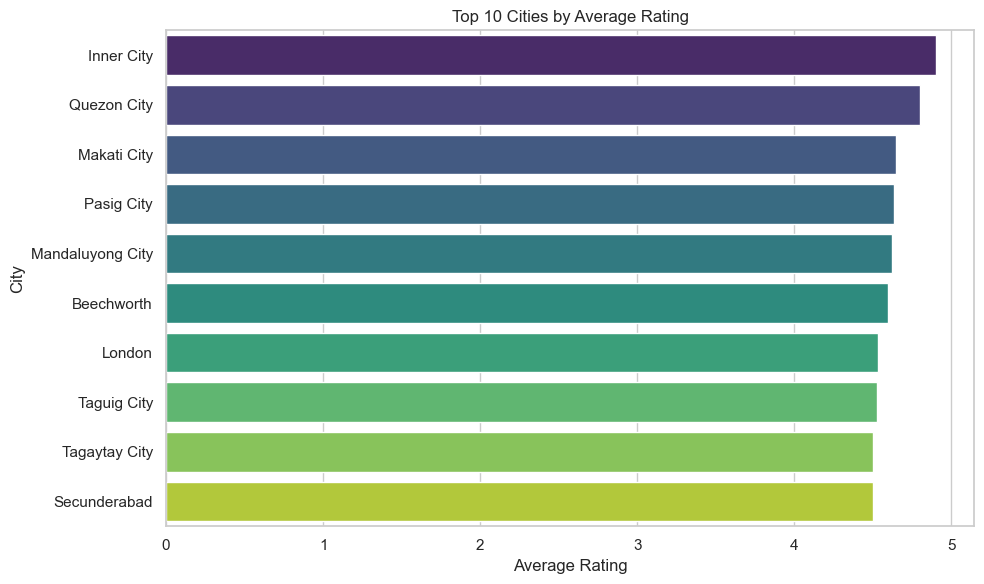

In [83]:
##  Average Ratings by City
plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_cities.values,
    y=top_cities.index,
    hue=top_cities.index,
    palette="viridis",
    dodge=False,
    legend=False
)
plt.title("Top 10 Cities by Average Rating")
plt.xlabel("Average Rating")
plt.tight_layout()
plt.savefig("avg_rating_by_city_fixed.png", dpi=300)
plt.show()



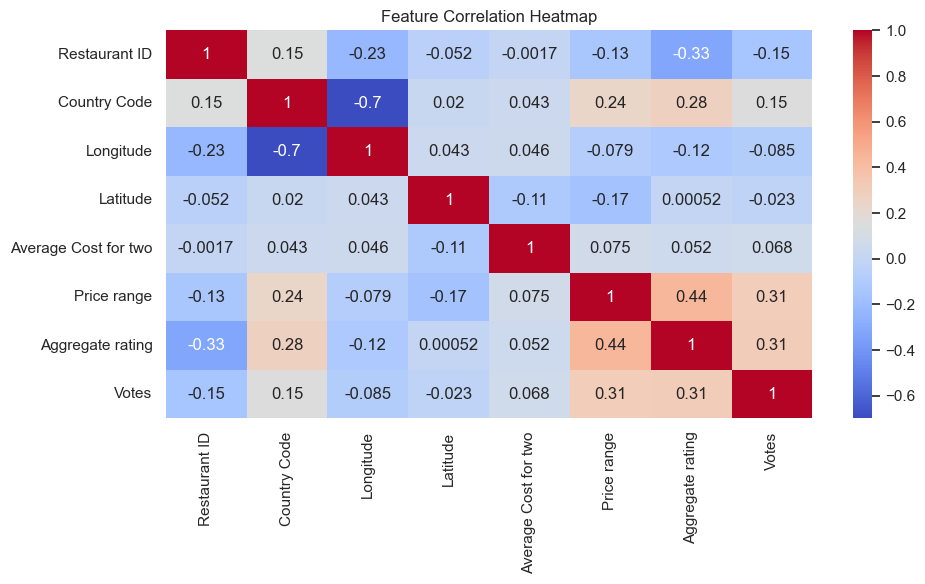

In [84]:
## Correlation Between Features and Rating
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300)
plt.show()


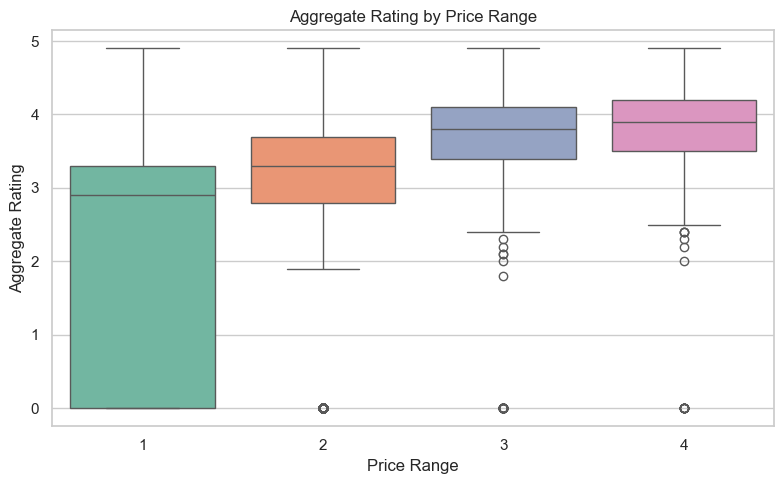

In [88]:
##  Boxplot of Ratings by Price Range
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="Price range",
    y="Aggregate rating",
    hue="Price range",            # Add this line
    data=df,
    palette="Set2",
    dodge=False,
    legend=False
)
plt.title("Aggregate Rating by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Aggregate Rating")
plt.tight_layout()
plt.savefig("rating_by_price_range_fixed.png", dpi=300)
plt.show()


## ✅ Task 3:  Completed


🔍 Price Range Analysis
Determined the most common price range across all restaurants.

Calculated the average Aggregate rating for each price range.

Identified the color representing the highest average rating among different price ranges.

Visualized the price range distribution and average ratings using bar plots and count plots.




### 📌 Outcome:
Interactive map of restaurant locations 

Country-level distribution insights

Top cities based on average customer ratings